In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


In [4]:
df = pd.read_csv("/content/drive/MyDrive/mlops/carprices.csv")


In [5]:
print(df.head())

dummies = pd.get_dummies(df['Car Model'])

merged = pd.concat([df, dummies], axis='columns')
final = merged.drop(['Car Model', 'Mercedez Benz C class'], axis='columns')

print("\nProcessed Dataset:\n")
print(final.head())



  Car Model  Mileage  Sell Price($)  Age(yrs)
0    BMW X5    69000          18000         6
1    BMW X5    35000          34000         3
2    BMW X5    57000          26100         5
3    BMW X5    22500          40000         2
4    BMW X5    46000          31500         4

Processed Dataset:

   Mileage  Sell Price($)  Age(yrs)  Audi A5  BMW X5
0    69000          18000         6    False    True
1    35000          34000         3    False    True
2    57000          26100         5    False    True
3    22500          40000         2    False    True
4    46000          31500         4    False    True


In [6]:
X = final.drop('Sell Price($)', axis='columns')
y = final['Sell Price($)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)


In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

prediction1 = model.predict([[45000, 4, 0, 0]])

print("\nPrice of Mercedes Benz (4 years old, 45000 mileage):")
print(prediction1)




Price of Mercedes Benz (4 years old, 45000 mileage):
[36871.03077103]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [9]:
prediction2 = model.predict([[86000, 7, 1, 0]])

print("\nPrice of BMW X5 (7 years old, 86000 mileage):")
print(prediction2)




Price of BMW X5 (7 years old, 86000 mileage):
[18486.91353691]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [10]:
score = model.score(X_test, y_test)

print("\nModel Accuracy Score:")
print(score)




Model Accuracy Score:
0.8675370464375716


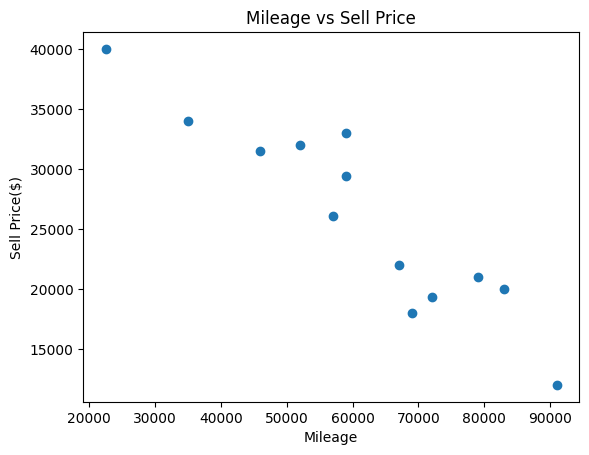

In [11]:
plt.scatter(df['Mileage'], df['Sell Price($)'])
plt.xlabel("Mileage")
plt.ylabel("Sell Price($)")
plt.title("Mileage vs Sell Price")
plt.show()